# Logistic Regression Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- Logistic Regression classifier (sklearn)
- Handles class imbalance with `class_weight`
- Feature scaling with `StandardScaler`
- Records training time, scoring time, and model performance

In [ ]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.model_data import load_and_split, save_sorted_features

## 1. Load Data & Selected Features

In [ ]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES = 50  # ← change this to use a different number of top-ranked features

# Write output/sorted_features.csv (columns ordered by rank) once
save_sorted_features()

Total consumers: 12900
Selected features: 50
Delinquency rate: 8.86%


## 2. Prepare Data & Train/Val/Test Split

In [ ]:
# Load features and perform 60/20/20 stratified split
X_train, X_val, X_test, y_train, y_val, y_test, available_features, features_df = \
    load_and_split(n_features=N_FEATURES)

# Scale features (Logistic Regression requires scaling; fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Features used: 50
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


## 3. Train Logistic Regression Model (Top-50 Features)

In [16]:
# Compute class weight to handle imbalance
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)
scale_pos_weight = n_neg / n_pos
class_weight = {0: 1.0, 1: scale_pos_weight}
print(f'Class weight for positive class: {scale_pos_weight:.2f}')

# Train Logistic Regression
model = LogisticRegression(
    solver='saga',
    penalty='l2',
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight=class_weight,
)

print('\nTraining Logistic Regression (top-50 features)...')
t0 = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - t0

print(f'Training completed in {training_time:.2f}s')

Class weight for positive class: 10.30

Training Logistic Regression (top-50 features)...
Training completed in 2.77s


## 4. Evaluation on All Splits

In [17]:
def evaluate(model, X_scaled, y_true, split_name):
    """Evaluate a sklearn model and print metrics."""
    scoring_start = time.time()

    # Predict probabilities for positive class
    y_proba = model.predict_proba(X_scaled)[:, 1]

    scoring_time = time.time() - scoring_start

    auc = roc_auc_score(y_true, y_proba)
    ap  = average_precision_score(y_true, y_proba)

    # Binary predictions at 0.5 threshold
    y_pred = (y_proba >= 0.5).astype(int)

    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time: {scoring_time:.4f} seconds')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))

    return y_proba, auc, ap, scoring_time


train_preds, train_auc, train_ap, train_time = evaluate(model, X_train_scaled, y_train, 'TRAIN')
val_preds,   val_auc,   val_ap,   val_time   = evaluate(model, X_val_scaled,   y_val,   'VALIDATION')
test_preds,  test_auc,  test_ap,  test_time  = evaluate(model, X_test_scaled,  y_test,  'TEST')


TRAIN Results
ROC-AUC: 0.7856
Average Precision: 0.2406
Scoring Time: 0.0019 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.96      0.71      0.82      5642
          DQ       0.20      0.73      0.31       548

    accuracy                           0.71      6190
   macro avg       0.58      0.72      0.56      6190
weighted avg       0.90      0.71      0.77      6190

Confusion Matrix:
[[4010 1632]
 [ 147  401]]

VALIDATION Results
ROC-AUC: 0.7343
Average Precision: 0.1844
Scoring Time: 0.0049 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.95      0.68      0.79      1880
          DQ       0.16      0.64      0.26       183

    accuracy                           0.68      2063
   macro avg       0.56      0.66      0.53      2063
weighted avg       0.88      0.68      0.75      2063

Confusion Matrix:
[[1276  604]
 [  65  118]]

TEST Results
ROC-AUC: 0.7378
A

## 5. Precision-Recall Curves

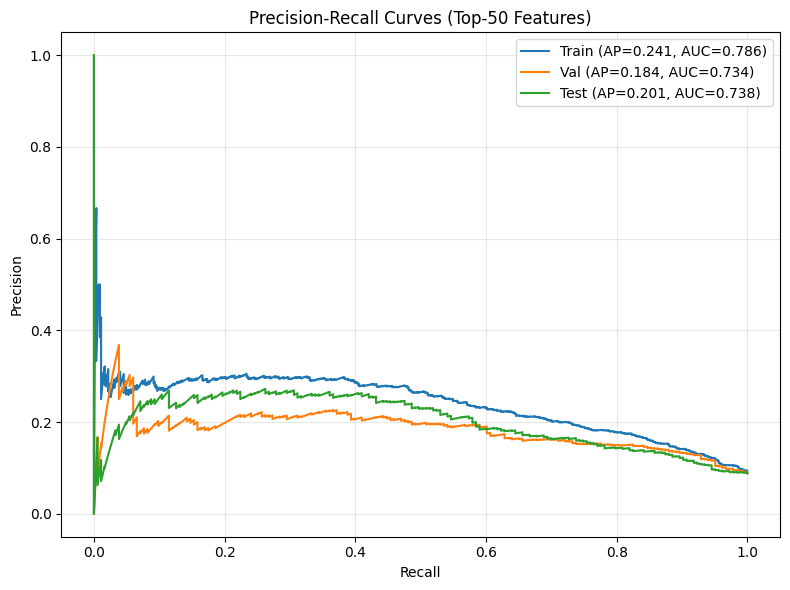

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_val in [
    (train_preds, y_train, 'Train', train_auc),
    (val_preds,   y_val,   'Val',   val_auc),
    (test_preds,  y_test,  'Test',  test_auc),
]:
    precision, recall, _ = precision_recall_curve(targets, preds)
    ap = average_precision_score(targets, preds)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f}, AUC={auc_val:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Top-50 Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary (Top-50 Features)

In [19]:
print('Logistic Regression – Top-50 Features Summary')
print('=' * 55)
print(f'Solver:          saga')
print(f'Penalty:         L2  |  C: 1.0')
print(f'Features used:   {len(available_features)}')
print(f'Training Time:   {training_time:.2f}s ({training_time/60:.2f} min)')
print()
print(f'{"Split":<12} {"ROC-AUC":<12} {"Avg Precision":<16} {"Scoring Time":<14}')
print(f'{"-"*54}')
print(f'{"Train":<12} {train_auc:<12.4f} {train_ap:<16.4f} {train_time:<14.4f}s')
print(f'{"Val":<12} {val_auc:<12.4f} {val_ap:<16.4f} {val_time:<14.4f}s')
print(f'{"Test":<12} {test_auc:<12.4f} {test_ap:<16.4f} {test_time:<14.4f}s')

Logistic Regression – Top-50 Features Summary
Solver:          saga
Penalty:         L2  |  C: 1.0
Features used:   50
Training Time:   2.77s (0.05 min)

Split        ROC-AUC      Avg Precision    Scoring Time  
------------------------------------------------------
Train        0.7856       0.2406           0.0019        s
Val          0.7343       0.1844           0.0049        s
Test         0.7378       0.2010           0.0000        s


---
# Logistic Regression – All Features

Same setup but using **every available feature** instead of the top-50 selection.

In [ ]:
# ── Use ALL features ─────────────────────────────────────────────
X_train_all, X_val_all, X_test_all, y_train_all, y_val_all, y_test_all, all_feature_cols, _ = \
    load_and_split(use_all=True)

# Scale (fit on train only)
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_val_all_scaled   = scaler_all.transform(X_val_all)
X_test_all_scaled  = scaler_all.transform(X_test_all)

Total features: 217
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


In [21]:
# ── Train Logistic Regression (all features) ─────────────────────
n_neg_all = np.sum(y_train_all == 0)
n_pos_all = np.sum(y_train_all == 1)
scale_pos_weight_all = n_neg_all / n_pos_all
class_weight_all = {0: 1.0, 1: scale_pos_weight_all}
print(f'Class weight for positive class: {scale_pos_weight_all:.2f}')

model_all = LogisticRegression(
    solver='saga',
    penalty='l2',
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight=class_weight_all,
)

print('\nTraining Logistic Regression (all features)...')
t0_all = time.time()
model_all.fit(X_train_all_scaled, y_train_all)
training_time_all = time.time() - t0_all

print(f'Training completed in {training_time_all:.2f}s')

Class weight for positive class: 10.30

Training Logistic Regression (all features)...
Training completed in 10.66s


In [22]:
# ── Evaluation (all features) ────────────────────────────────────
train_preds_all, train_auc_all, train_ap_all, train_time_all = evaluate(
    model_all, X_train_all_scaled, y_train_all, 'TRAIN (all features)')
val_preds_all, val_auc_all, val_ap_all, val_time_all = evaluate(
    model_all, X_val_all_scaled, y_val_all, 'VALIDATION (all features)')
test_preds_all, test_auc_all, test_ap_all, test_time_all = evaluate(
    model_all, X_test_all_scaled, y_test_all, 'TEST (all features)')


TRAIN (all features) Results
ROC-AUC: 0.8288
Average Precision: 0.2998
Scoring Time: 0.0033 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.97      0.73      0.83      5642
          DQ       0.22      0.78      0.34       548

    accuracy                           0.73      6190
   macro avg       0.59      0.75      0.59      6190
weighted avg       0.90      0.73      0.79      6190

Confusion Matrix:
[[4098 1544]
 [ 119  429]]

VALIDATION (all features) Results
ROC-AUC: 0.7365
Average Precision: 0.1916
Scoring Time: 0.0020 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.95      0.69      0.80      1880
          DQ       0.17      0.65      0.27       183

    accuracy                           0.69      2063
   macro avg       0.56      0.67      0.54      2063
weighted avg       0.88      0.69      0.76      2063

Confusion Matrix:
[[1305  575]
 [  64  119]]



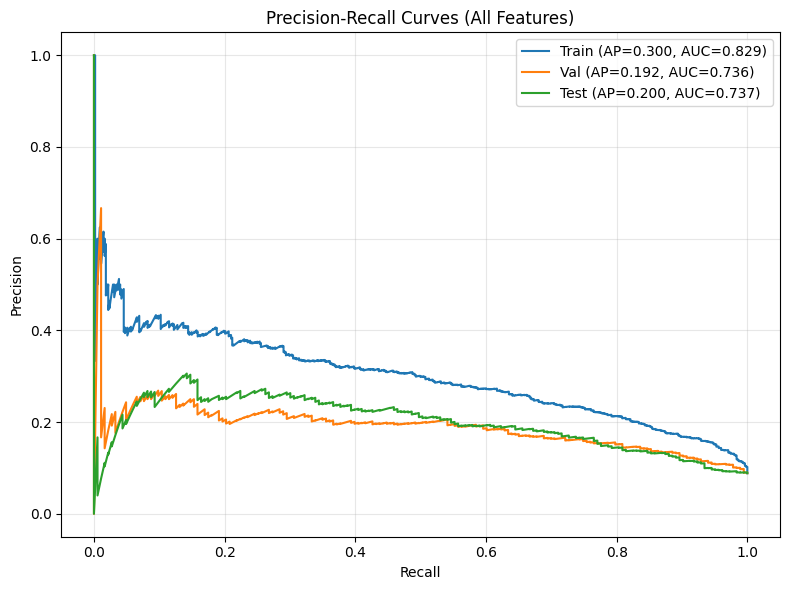

In [23]:
# ── Precision-Recall Curves (all features) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_v in [
    (train_preds_all, y_train_all, 'Train', train_auc_all),
    (val_preds_all,   y_val_all,   'Val',   val_auc_all),
    (test_preds_all,  y_test_all,  'Test',  test_auc_all),
]:
    prec, rec, _ = precision_recall_curve(targets, preds)
    ap_v = average_precision_score(targets, preds)
    ax.plot(rec, prec, label=f'{name} (AP={ap_v:.3f}, AUC={auc_v:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (All Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Comparison Summary: Top-50 vs All Features

In [24]:
# ── Comparison: Top-50 Features vs All Features ──────────────────
print('Comparison: Top-50 Features vs All Features (Logistic Regression)')
print('=' * 72)
print(f'{"Metric":<24} {"Top-50":<22} {"All Features":<22}')
print(f'{"-"*68}')
print(f'{"Num features":<24} {len(available_features):<22} {len(all_feature_cols):<22}')
print(f'{"Training time (s)":<24} {training_time:<22.2f} {training_time_all:<22.2f}')
print()
print(f'{"Split":<8} {"Metric":<18} {"Top-50":<14} {"All Features":<14}')
print(f'{"-"*54}')
for split, (auc50, ap50, t50, auca, apa, ta) in {
    'Train': (train_auc, train_ap, train_time, train_auc_all, train_ap_all, train_time_all),
    'Val':   (val_auc,   val_ap,   val_time,   val_auc_all,   val_ap_all,   val_time_all),
    'Test':  (test_auc,  test_ap,  test_time,  test_auc_all,  test_ap_all,  test_time_all),
}.items():
    print(f'{split:<8} {"ROC-AUC":<18} {auc50:<14.4f} {auca:<14.4f}')
    print(f'{"":8} {"Avg Precision":<18} {ap50:<14.4f} {apa:<14.4f}')
    print(f'{"":8} {"Score time (s)":<18} {t50:<14.4f} {ta:<14.4f}')

Comparison: Top-50 Features vs All Features (Logistic Regression)
Metric                   Top-50                 All Features          
--------------------------------------------------------------------
Num features             50                     217                   
Training time (s)        2.77                   10.66                 

Split    Metric             Top-50         All Features  
------------------------------------------------------
Train    ROC-AUC            0.7856         0.8288        
         Avg Precision      0.2406         0.2998        
         Score time (s)     0.0019         0.0033        
Val      ROC-AUC            0.7343         0.7365        
         Avg Precision      0.1844         0.1916        
         Score time (s)     0.0049         0.0020        
Test     ROC-AUC            0.7378         0.7368        
         Avg Precision      0.2010         0.1996        
         Score time (s)     0.0000         0.0000        
